### *BONUS. PYTHON-15. Принципы ООП в Python и отладка кода


Объекты и классы

Задание 3.2 (External resource)
Определите пустой класс с именем DepartmentReport.
Обратите внимание, что от вас требуется только объявить класс. Создавать экземпляров класса не нужно!

In [1]:
class DepartmentReport():
    pass


In [4]:
department_report = DepartmentReport()

print(type(department_report))

<class '__main__.DepartmentReport'>


Атрибуты и методы

Мы создали объект по пустому классу. Давайте добавим ему данные. Сделаем класс для отчётов по продажам SalesReport. Пусть у нас в компании есть менеджеры по продажам, которые заключают сделки, и мы хотим посчитать для них метрики общего объёма продаж.

In [ ]:
# По-прежнему пока создаём пустой класс  
class SalesReport():
    pass 

# Создаем первый свой отчет по продажам 
report = SalesReport()

# Мы добавим новый атрибут объекту. 
# Для этого через точку напишем имя атрибута и дальше как с обычной переменной 
report.amount = 10 

# Тоже самое делаем для второго отчета 
report_2 = SalesReport()
report_2.amount =20 

# создатим вспомогательную функцию, она будет печатать общую сумму из отчёта 
def print_report(report): 
    print('Total amount:', report.amount)

print_report(report)
print_report(report_2)



Total amount: 10
Total amount: 20


Для разных отчётов вывелись разные значения, хотя объекты создавались из одного класса. Функция print_report делает операцию над отчётом. Так как классы увязывают данные и действия над ними, положим print_report внутрь класса.

In [7]:
# Наш новый метод внутри класса
# Мы определяем его похожим образом с обычными функциями 
# но только помещаем внутрь класса и первым аргументом передаем self
class SalesReport():
    def print_report(self): 
        print('Total amount:', self.amount)
        
        
# Дальше мы применяем report так же, как и в примере выше 
report = SalesReport()
report_2 = SalesReport()
report.amount = 11
report_2.amount = 21 

report.print_report()
report_2.print_report()



Total amount: 11
Total amount: 21


Давайте для примера определим ещё пару методов в класс. 


Атрибут deals, определённый в одном методе, становится доступен сразу во всех методах класса. Через self становятся доступны и остальные методы, например print_report использует метод total_amount. Это позволяет компактно упаковывать логику внутри класса: внешнее использование становится гораздо лаконичнее.

In [ ]:
class SalesReport():
    # Позволим добавить много разных сделок 
    def add_deal(self, amount): 
        # На первой сделке создадим список для хранения всех сделок 
        # проверку наличия атрибута можно выполнить с помощью встроенной функции hasattr()
        if not hasattr(self, 'deals'):
            self.deals = []
        # Добавим текущую сделку 
        self.deals.append(amount)
        
    # Посчитаем сумму всех сделок 
    def total_amount(self): 
        return sum(self.deals)
    
    def print_report(self): 
        print('Total sales:', self.total_amount())
        
# используем наши новые возможности 
# добавляем две сделки и распечатываем отчёт

report = SalesReport()
report.add_deal(10_000)
report.add_deal(34_000)
report.print_report()

Total sales: 44000


Задание 4.1 (External resource)
Допишите определение класса DepartmentReport, который выводит отчёт по отделам компании. У него должны быть определены:

-- свойство revenues — список, где мы храним значения выручки отделов;

-- метод add_revenue(), который добавляет выручку одного отдела в список revenues. Если списка revenues еще не существует, метод должен его создавать (проверку наличия атрибута можно выполнить с помощью встроенной функции hasattr());

-- метод average_revenue(), который возвращает среднюю выручку по всем отделам (считает среднее по списку revenues).
Обратите внимание, что от вас требуется только объявить класс. Создавать экземпляров класса не нужно!

In [24]:
class DepartmentReport(): 
    def add_revenue(self, amount):
        # Метод для добавления выручки отдела в список revenues.
        # Если атрибута revenues ещё не существует, метод должен создавать пустой список перед добавлением выручки.
        if not hasattr(self, 'revenues'):
            self.revenues = []
        self.revenues.append(amount)
         
    def average_revenue(self):
        #     Метод возвращает среднюю выручку по отделам.
        return (sum(self.revenues) / len(self.revenues))
    
    def print_report(self):
        print(self)


r = DepartmentReport()
r.add_revenue(1_000_000)
r.add_revenue(400_000)
print(r.average_revenue())

700000.0


### Метод _INIT_

Мы определили несколько методов в классе SalesReport. С ним есть пара проблем. 

Если мы вызовем total_amount до add_deal, то список сделок ещё не будет создан, и мы получим ошибку. Также проверка на наличие списка в методе add_deal не кажется оптимальным решением, потому что создать список нужно один раз, а проверять его наличие мы вынуждены на каждой сделке.

вот такая ошибка будет 


In [17]:
class SalesReport():
    def add_deal(self, amount): 
        if not hasattr(self, 'deals'):
            self.deals = []
        self.deals.append(amount)
        
    def total_amount(self): 
        return sum(self.deals)
    
    def print_report(self): 
        print('Total sales:', self.total_amount())
        
report = SalesReport()
report.total_amount()

AttributeError: 'SalesReport' object has no attribute 'deals'

Обе проблемы решились бы, если задавать атрибутам исходное значение. Для этого у классов есть метод инициализации __init__. Если мы определим метод с таким именем, код в нём вызовется при создании объекта.



In [20]:
class SalesReport():
    def __init__(self):
        self.deals=[]
    def add_deal(self, amount): 
        self.deals.append(amount)
        
    def total_amount(self): 
        return sum(self.deals)
    
    def print_report(self): 
        print('Total sales:', self.total_amount())
        
report = SalesReport()
print(report.deals)
report.total_amount()

[]


0

При создании отчёта вызвался __init__, deals определился в нём пустым списком и проблемы ушли. 

__init__ — это технический метод, поэтому его имя начинается и заканчивается двумя подчёркиваниями. Он получает первым аргументом сам объект, в нём могут выполняться любые операции. Оставшиеся аргументы он получает из вызова при создании: если мы напишем report = SalesReport("Info", 20), то вторым и третьим аргументом в __init__ передадутся "Info" и 20.

In [22]:
class SalesReport():
    # Будем принимать в __unit__ ещё и имя менеджера 
    def __init__(self, manager_name):
        self.deals=[]
        self.manager_name = manager_name
    
    def add_deal(self, amount): 
        self.deals.append(amount)
        
    def total_amount(self): 
        return sum(self.deals)
    
    def print_report(self): 
        # И добавлять это имя в отчёт 
        print('Manager:', self.manager_name)
        print('Total sales:', self.total_amount())
        
report = SalesReport('Ruslan Victim')
report.add_deal(10_900)
report.add_deal(22_900)

report.print_report()

Manager: Ruslan Victim
Total sales: 33800


Задание 4.2 (External resource)

Улучшите класс DepartmentReport, добавив в него инициализатор.

Класс при инициализации должен принимать переменную company_name и инициализировать её значением свойство company, а также инициализировать свойство revenues пустым списком.

Также модифицируйте метод average_revenue. Теперь он должен возвращать строку следующего вида "Average department revenue for <company_name>: <average_revenue>".
Обратите внимание, что от вас требуется только объявить класс. Создавать экземпляров класса не нужно!


In [ ]:
class DepartmentReport(): 
    # Класс при инициализации должен принимать переменную company_name 
    def __init__(self, company_name):
        # Инициализировать свойство revenues пустым списком
        self.revenues=[]
        # Инициализировать её значением свойство company
        self.company = company_name
    
    
    def add_revenue(self, amount):
        self.revenues.append(amount)
         
    def average_revenue(self):
        #     Метод возвращает среднюю выручку по отделам.
        self_avarage = sum(self.revenues) / len(self.revenues)
        
        return (f'Average department revenue for {self.company}: {self_avarage}')
    
    def print_report(self):
        print(self)
        #print('Average department revenue for <company_name>: <average_revenue>',self.average_revenue())


r = DepartmentReport(company_name='Danon')
#print(r.company)
r.add_revenue(1_000_000)
r.add_revenue(400_000)
print(r.average_revenue())

Average department revenue for Danon: 700000.0


### краткое резюме

✔️ Мы рассмотрели базовый синтаксис классов и синтаксис создания объектов. Давайте вспомним некоторые важные моменты:

атрибут объекта — это просто его переменная;
метод объекта — это его функция;
метод объекта автоматически получает первым аргументом сам объект под именем self;
класс описывает объект через его атрибуты и методы;
мы можем создавать множество экземпляров одного класса, и значения их атрибутов независимы друг от друга;
если определить метод __init__, то он будет выполняться при создании объекта;
всё это позволяет компактно увязывать данные и логику внутри объекта.

Чтобы продемонстрировать, что мы имеем в виду под компактностью, давайте добавим ещё метрик в отчёт. 

Допустим, теперь мы хотим получать средний размер сделки и список клиентов, из которого исключены повторения (в случае, если компания заключала несколько сделок с одним и тем же клиентом).

In [58]:
class SalesReport():
    # Будем принимать в __unit__ ещё и имя менеджера 
    def __init__(self, employee_name):
        self.deals=[]
        self.employee_name = employee_name
    
    def add_deal(self, company, amount): 
        self.deals.append({'company': company, 'amount':amount})
        
    def total_amount(self): 
        return sum([deal['amount'] for deal in self.deals])
    
    def average_deal(self):
        return self.total_amount()/len(self.deals)

    def all_companies(self): 
        return list(set([deal['company'] for deal in self.deals]))
    
    def print_report(self): 
        print('Employee:', self.employee_name)
        print('Total sales:', self.total_amount())
        print('Average sales:', self.average_deal())
        print('Companies:', self.all_companies())

report = SalesReport('Ruslan Victim')
report.add_deal('Ford', 10_900)
report.add_deal('Ferrari', 255_900)
report.add_deal('Toyota', 75_900)

report.print_report()

Employee: Ruslan Victim
Total sales: 342700
Average sales: 114233.33333333333
Companies: ['Ford', 'Ferrari', 'Toyota']


### Практические примеры


Разница в том, что для ряда задач ООП является более подходящим инструментом и позволяет решать их проще. Рассмотрим ещё несколько примеров — это поможет вам развить интуицию и понять, в каких ситуациях стоит рассматривать переход от простых функций к классам.

Отслеживание состояния

Одно из классических предписаний для классов — у каждого из множества объектов есть некоторые меняющиеся состояния. 

Вернёмся к примеру: есть база клиентов с основной информацией; в реальном времени нам приходит информация о покупках. Запустим промокампанию, чтобы поощрить старых клиентов, которые сделали у нас много заказов, и выдать им скидку:

In [75]:
class Client(): 
    # Базовые данные 
    def __init__(self, email, order_num,registration_year):
        self.email = email 
        self.order_num = order_num 
        self.registration_year = registration_year
        self.discount = 0 
        
    # Оформление заказа 
    def make_order(self, price):
        self.update_discount()
        self.order_num +=1
        # Здесь было бы оформление заказа, но мы просто выведем его цену 
        discounted_price = price *(1 - self.discount)
        print(f'Order price for {self.email} is {discounted_price}')
        
    # Назначение скидки 
    def update_discount(self): 
        if self.registration_year < 2018 and self.order_num >= 5: self.discount = 0.1
        
# Примечание 
# Сделаем подобие базы 
client_db = [Client('sdd@sdsd.com', 2, 2019),
             Client('lova@udnaex.ru', 19, 2015),
             Client('hjhjh@fgkfg.ru', 4, 2022)]

# Сгенерируем заказы 
client_db[0].make_order(100)
client_db[1].make_order(180)
client_db[2].make_order(500)
client_db[2].make_order(450)

Order price for sdd@sdsd.com is 100
Order price for lova@udnaex.ru is 162.0
Order price for hjhjh@fgkfg.ru is 500
Order price for hjhjh@fgkfg.ru is 450


Задание 5.1 (External resource)

Мы разрабатываем приложение, которое подразумевает функционал авторизации пользователя, а также управление его балансом на некотором виртуальном счете.

Определите класс для пользователей User.

У него должны быть:

атрибуты email, password и balance, которые устанавливаются при инициализации в методе __init__();
метод login(), который реализует проверку почты и пароля. Метод должен принимать в качестве аргументов емайл (email) и пароль (password). Если они совпадают с атрибутами объекта, он возвращает True, а иначе — False;
метод update_balance(), который должен принимать в качестве аргумента amount некоторое число и изменять текущий баланс счёта (атрибут balance) на величину amount.
В случае правильного описания класса код, приведённый ниже, должен выдать следующий результат:

Пример использования класса:
user = User("gosha@roskino.org", "qwerty", 20_000)

print(user.login("gosha@roskino.org", "qwerty123"))

False

print(user.login("gosha@roskino.org", "qwerty"))

True

user.update_balance(200)

user.update_balance(-500)

print(user.balance)

19700

Обратите внимание, что от вас требуется только объявить класс. Создавать экземпляров класса не нужно!

In [112]:
class User(): 
    def __init__(self, email, password, balance):
        self.email = email
        self.password = password
        self.balance = balance 
        
        
    # Метод который реализует проверку почты и пароля. Метод должен принимать в качестве аргументов емайл (email) и пароль (password). 
    # Если они совпадают с атрибутами объекта, он возвращает True, а иначе — False;
    def login(self,email, password):
        if email == self.email and password==self.password: display = True
        else: display=False
        return display
        
        
    
    # метод update_balance(), который должен принимать в качестве аргумента 
    # amount некоторое число и изменять текущий баланс счёта (атрибут balance) на величину amount.
    def update_balance(self,amount):
        self.balance = self.balance + amount 
        return self.balance
    
user = User("gosha@roskino.org", "qwerty", 20_000)
print(user.login("gosha@roskino.org", "qwerty"))
user.update_balance(200)
user.update_balance(-500)

True


19700

### Комбинация операций

Классы могут пригодиться, если вы регулярно делаете над данными одну и ту же последовательность разноплановых функций. Вы можете упаковать их в класс и в дальнейшем сразу получать результат по загруженным данным.

У нас есть численные данные из разных источников. Если они в виде строк, то нужно привести их к числам, а пропуски — заполнить значениями. Сделаем доступ к медиане, среднему значению и стандартному отклонению:

In [118]:
import statistics
class DataFrames(): 
    def __init__(self, column, fill_value = 0): 
        # Инициализируем атрибуты 
        self.column = column
        self.fill_value = fill_value 
        # Заполняем пропуски 
        self.fill_missed()
        # Конвертируем все элементы в числа 
        self.to_float()
    def fill_missed(self): 
        for i,value in enumerate(self.column):
            if value is None or value =='':
                self.column[i] = self.fill_value
                
    def to_float(self): 
        self.column = [float(value) for value in self.column]
        
    def median(self): 
        return statistics.median(self.column)
    
    def mean(self):
        return statistics.mean(self.column)
    
    def deviation(self): 
        return statistics.stdev(self.column)            
    
# воспользуемся классом 
ds = DataFrames(['1', 17,4, None,8])
    
print(ds.column)
print(ds.deviation())
print(ds.median())
    

[1.0, 17.0, 4.0, 0.0, 8.0]
6.892024376045111
4.0


Мы получили очень лаконичный интерфейс для использования класса. В __init__ мы использовали значение по умолчанию для fill_value, а методы позволяют нам определять необязательные параметры.

### Задание 5.2 (External resource)

Определите класс IntDataFrame, который в момент инициализации объектов принимает список неотрицательных чисел и приводит к целым значениям все числа в этом списке, отрезая дробную часть с помощью встроенной функции int().

Результирующий список должен быть сохранен в виде атрибута с именем column.

Также класс должен содержать следующие методы:

count(), который возвращает количество ненулевых элементов в списке column;

unique(), который возвращает число уникальных элементов в списке в списке column.

В случае правильного описания класса код, приведённый ниже, должен выдать следующий результат:

Пример использования класса:


df = IntDataFrame([4.7, 4, 3, 0, 2.4, 0.3, 4])

print(df.column)
=> [4, 4, 3, 0, 2, 0, 4]

print(df.count())
=> 5

print(df.unique())
=> 4


In [ ]:
# МОЕ РЕШЕНИЕ 
class IntDataFrame(): 
    def __init__(self, column):
        self.column = column
        self.convert_int()
        self.count()
# (!!!) тут прикольная тема, что новый список, мы тупо в скобки списка засовываем цикл в одну строчку. и все. 
# стандартно это бы выглядило вот так     
#   def convert_int(self): 
#       list_s = []
#       for i in self.column:
#          list_s.append(int(i))
#          self.column = list_s
    
    def convert_int(self): 
        self.column = [int(value) for value in self.column]       
    
    def count(self): 
        list_null = []
        for i in self.column: 
            if i > 0: list_null.append(i)
        return len(list_null)
    def unique(self): 
        list_unique = []
        for i in self.column:
            if i not in list_unique: list_unique.append(i)
        
        return len(list_unique)    
        
df = IntDataFrame([4.7, 4, 3.55, 0, 2.4, 0.3, 4])

print(df.column)
print(df.count())
print(df.unique())

[4, 4, 3, 0, 2, 0, 4]
5
4


### Эталонное решение Задание 5.2 (External resource)

In [ ]:
class IntDataFrame():
    def __init__(self, column):
        # заходим через map, и в иницилизирующей функции, сразу делаем обработку списка. 
        # map позволяет работать с элементами списка без цикла. обворачиваем все в список, перебираем каждый элемент
        # и на каждый элемент накидываем лямбду, в которой просто интуем каждый элемент. Великолепно 
        self.column = list(map(lambda x: int(x), column))
    
    # здесь же, действуйем через функцию фильтр и лямбду, которая позволяет отставлять всписке то, что нам надо, и 
    # измерять длиннну данного списка. 
    def count(self):
        return len(list(filter(lambda x: x!=0, self.column)))
    # здесб мы просто идем через встроенный тип данных set - множиство, который не позволяет содержать в себе одинаковые элементы, 
    # только уникальные. 
    def unique(self):
        return len(set(self.column))

## Класс-обёртка 



Классы можно использовать тогда, когда у вас есть процесс, который требует сложной конфигурации, повторяющейся из раза в раз. Можно написать класс-обёртку, который сведёт этот процесс к одному-двум методам.

Представим, вы делаете обработку данных и в конце каждого дня сохраняете результат в архив. Вы хотите, чтобы данные каждого дня лежали в отдельном файле для этого дня, при этом можно было бы получить данные за произвольный день. 

In [187]:
import pickle 
from datetime import datetime
from os import path 

class Dumper (): 
    def __init__(self, archive_dir = 'archive/'): 
        self.archive_dir = archive_dir 
    def dump(self, data): 
        # Библиотека pickle позволяет доставать и класть объекты в файл 
        with open(self.get_file_name(), 'wb') as file:
            pickle.dump(data, file)
            
    def load_for_day(self, day): 
        file_name = path.join(self.archive_dir, day + '.pkl')
        with open(file_name, 'rb') as file: 
            sets = pickle.load(file)
        return sets 
    
    # возвращает корректно имя для файла 
    def get_file_name(self): 
        today = datetime.now().strftime('%y-%m-%d')
        return path.join(self.archive_dir, today + '.pkl')
    
# Пример использования 

data = {'performance':[10,20,10], 'clients': {'Romashka':10, 'Vector':34}}

dumper = Dumper()

# Сохраним данные 
dumper.dump(data)

# восстановим для сегодняшней даты 
file_name = datetime.now().strftime('%y-%m-%d')
restored_data = dumper.load_for_day(file_name)
print(restored_data)

{'performance': [10, 20, 10], 'clients': {'Romashka': 10, 'Vector': 34}}


### Задание 5.3

Напишите класс сборщика технических сообщений OwnLogger.

У него должен быть

-- атрибут logs, содержащий {"info": None, "warning": None, "error": None, "all": None}.

-- метод log(message, level), который записывает сообщения. Здесь сообщение message может быть любым, а level — один из "info", "warning", "error".

-- метод show_last(level), где level может быть "info", "warning", "error", "all".
Для "all" он просто возвращает последнее добавленное сообщение, а для остальных — последнее поступившее сообщение соответствующего уровня. При этом по умолчанию значение именно "all".

Если подходящего сообщения нет, возвращает None.

В случае правильного описания класса код, приведённый ниже, должен выдать следующий результат:



logger = OwnLogger()
logger.log("System started", "info")
logger.show_last("error")
None
Некоторые интерпретаторы Python могут не выводить None, тогда в этой проверке у вас будет пустая строка
logger.log("Connection instable", "warning")
logger.log("Connection lost", "error")

logger.show_last()
Connection lost
logger.show_last("info")
System started


_тупорылая задача, я условия не понял ее, поэтому сделать не удалось_

In [195]:
class OwnLogger():
    
    def __init__(self):
        self.logs = {'info':None, 'warning':None, 'error':None, 'all':None}
        
    def log(self, message, level): 
        self.logs[level] = message
        self.logs['all'] = message
                
    def show_last(self, level = 'all'):
        return self.logs[level] 
        
print(OwnLogger().logs)

{'info': None, 'warning': None, 'error': None, 'all': None}


In [197]:
res = OwnLogger()
res.log(message='System started', level='info')
res.log(message='System started 2', level='info')
res.log(message='Warning message', level='warning')
print(res.show_last())

Warning message


In [198]:
res = OwnLogger()
res.log(message='System started', level='info')
res.log(message='System started 2', level='info')
res.log(message='Warning message', level='warning')

print(res.show_last(level='info'))

System started 2


In [199]:
res = OwnLogger()
res.log(message='System started', level='info')
res.log(message='System started 2', level='info')
res.log(message='Warning message', level='warning')

print(res.show_last(level='error'))

None


Задание 6.3 (External resource)

Определите класс Dog, у которого есть методы bark и give_paw. При этом, пусть методы принимают список из любого количества аргументов.

bark возвращает строку "Bark!"
give_paw возвращает строку "Paw"

In [ ]:
class Dog(): 
    def __init__(self):
        self.bark()
        self.give_paw()
    
    def bark(self, list_bark = []):
        return 'Bark!'
    def give_paw(self,list_bark = []): 
        return 'Paw'

print(Dog().bark(['Лайка', 'Бим']))

Bark!


### Применение ООП для работы с файлами

Задание 7.3

Задание на самопроверку.

Сделайте функцию, которая принимает от пользователя путь и выводит всю информацию о содержимом этой папки. Для реализации используйте функцию встроенного модуля os.walk(). Если путь не указан, то сравнение начинается с текущей директории.

In [ ]:
import os 

def walk_desc(path = None): 
    # определяем стартовый путь и получаем к нему доступ, если нет пути используй функцию получить доступ, либо иди по пути 
    start_path = path if path is not None else os.getcwd()
    
    # запускаем цикл по содержанию директории на файлы и другие сущности 
    for root, dirs, files in os.walk(start_path): 
        print('Текущая директория', root) # выводим путь директории
        print('---')
        if dirs: print('Список папок', dirs) # выводим список папок 
        else: print('Папок нет')
        print('---')
        
        if files: print('Список файлов', files) # выводим список файлов 
        else: print('Файлов нет')
        print('---') 
        
        # выводим все сущности в директории с полным абсолютным путем. 
        if files and dirs: print('Все пути:')
        for f in files: print('Файл', os.path.join(root, f))
        for d in dirs: print('Папка', os.path.join(root, d))
        print('===') 
        
walk_desc()


Текущая директория c:\Users\rus-l\Documents\12. Образование\Machine Learning\IDE
---
Список папок ['.git', 'archive', 'project0', 'project1', 'PYTHON-14. Очистка данных', 'PY_10_Введение в Pandas', 'Работа с Matplotlib, Seaborn и Plotly,']
---
Список файлов ['PYTHON-15. Принципы ООП.ipynb']
---
Все пути:
Файл c:\Users\rus-l\Documents\12. Образование\Machine Learning\IDE\PYTHON-15. Принципы ООП.ipynb
Папка c:\Users\rus-l\Documents\12. Образование\Machine Learning\IDE\.git
Папка c:\Users\rus-l\Documents\12. Образование\Machine Learning\IDE\archive
Папка c:\Users\rus-l\Documents\12. Образование\Machine Learning\IDE\project0
Папка c:\Users\rus-l\Documents\12. Образование\Machine Learning\IDE\project1
Папка c:\Users\rus-l\Documents\12. Образование\Machine Learning\IDE\PYTHON-14. Очистка данных
Папка c:\Users\rus-l\Documents\12. Образование\Machine Learning\IDE\PY_10_Введение в Pandas
Папка c:\Users\rus-l\Documents\12. Образование\Machine Learning\IDE\Работа с Matplotlib, Seaborn и Plotly,
=

### Работа с файлами

In [228]:
f = open('test.txt', 'w', encoding='utf8')

# Запишем в файл строку 
f.write('this is test string\n')
f.write('this is new string\n')
f.close()

In [ ]:
# Откроем файл для чтения, в который только что записали две строки:

f = open('test.txt', 'r', encoding = 'utf8')
print(f.read(25))
# После прочтения указатель на содержимое остается на той позиции, где чтение закончилось. Если n не указать, 
# будет прочитано «от печки», то есть от текущего места указателя и до самого конца файла.

this is test string
this 


In [231]:
# считали остаток файла 
f.read()

'is new string\n'

In [232]:
# обязательно закрываем файл
f.close()

### Чтение и запись построчно

Зачастую с файлами удобнее работать построчно, поэтому для этого есть отдельные методы:

writelines — записывает список строк в файл;
readline — считывает из файла одну строку и возвращает её;
readlines — считывает из файла все строки в список и возвращает их.
Метод f.writelines(sequence) не будет сам за вас дописывать символ конца строки ('\n'), поэтому при необходимости его нужно прописать вручную.

In [234]:
f = open('test.txt', 'a', encoding = 'utf8')
sequence = ['other string\n', '123\n', 'test test\n'] 
f.writelines(sequence) # берем строки из sequence и записывает в файл (без переноса)
f.close()


In [236]:
# Попробуем теперь построчно считать файл с помощью readlines: 
f = open('test.txt', 'r', encoding = 'utf8')
print(f.readlines()) # считываем все строки в список и возврат список 
f.close()

['this is test string\n', 'this is new string\n', 'other string\n', '123\n', 'test test\n']


In [ ]:
# Метод f.readline() возвращает строку (символы от текущей позиции до символа переноса строки):
f = open('test.txt', 'r', encoding = 'utf8')
print(f.readline())
print(f.read(4))
print(f.readline())
f.close()

this is test string

this
 is new string



### Файл как итератор
Не стоит считывать файл полностью — в большинстве задач с обработкой текста весь файл разом читать не требуется. В таком случае с файлом работают построчно.


In [239]:
f = open('test.txt')
for line in f: 
    print(line, end ='')
f.close()

this is test string
this is new string
other string
123
test test


Для явного указания места работы с файлом, а также чтобы не забывать закрывать файл после обработки, существует менеджер контекста with.

In [294]:
# В блоке менеджера контекста открытый файл "жив" и с ним можно работать, при выходе из блока - файл закрывается 

with open('test.txt', 'rb') as f: 
    a = f.read(10)
    b = f.read(23)
    
#f.read(3) 

### Задание 7.4
Создайте любой файл на операционной системе под название input.txt и построчно перепишите его в файл output.txt.

In [253]:
r = open('input.txt', 'w', encoding='utf8')

# Запишем в файл строку 
r.write('I will a Data Science\n')
r.write('it will be cool skills\n')
r.write('and i will got a couple competions with gold medal\n')
r.close()

In [254]:
r = open('input.txt')
g = open('output.txt', 'w', encoding='utf8')
for line in r:
    g.write(line)

g = open('output.txt')
print(g.read())

I will a Data Science
it will be cool skills
and i will got a couple competions with gold medal



Эталонное решение 

In [255]:
with open("input.txt", "r") as input_file:
    with open("output.txt", "w") as output_file:
        for line in input_file:
            output_file.write(line)

Задание 7.5

Дан файл numbers.txt, компоненты которого являются действительными числами (файл создайте самостоятельно и заполните любыми числам, в одной строке одно число). Найдите сумму наибольшего и наименьшего из значений и запишите результат в файл output.txt.

In [ ]:
# я пошел по сложному пути, получается решение глупым. а задача звучит проще. 
# я в своем решении генерю случаный массив с числами, который при каждом запуске новыый. 
# записываю его в строковом формате в список, потом этот список кидаю в файл, который потом мне надо прочитать 
# и распоковать обратно, перевести в надлежащий вид, найти мин и макс, и потом записать в другой файл. 
# сделаю в другой ячейки питона без пафоса первой части решения. 
import numpy as np 
h = np.random.randint(100, size = (1,5))
f = h[0][::]
g = []
for i in f: 
    g.append(str(i)+'\n')
with open('numbers.txt', 'w') as numbers_file:
    numbers_file.writelines(g)

numbers_file = open('numbers.txt', 'r')
g_2 = numbers_file.readlines()
print(g_2)

#print(numbers_file.read())
#print(f)





['3\n', '58\n', '35\n', '80\n', '19\n']


In [358]:
digit = ['34\n','16\n','7\n','88\n','1\n']
with open('numbers.txt', 'w') as numbers_file: 
    numbers_file.writelines(digit)

output_list = []
with open('numbers.txt', 'r') as numbers_file:
    output_list = numbers_file.readlines() 

output_list = list(map(lambda x:int(x[0:2]),output_list))
min_o = min(output_list)
max_o = max(output_list)
sum_o = max_o + min_o
output_file = open('output.txt', 'w')
output_file.write(str(sum_o))
output_file = open('output.txt', 'r')
print(output_file.read())


89


Задание 7.6

В текстовый файл построчно записаны фамилии и имена учащихся класса и их оценки за контрольную. Подсчитайте количество учащихся, чья оценка меньше 3 баллов. Cодержание файла:

In [381]:
student = ['Иванов О. 4\n', 'Петров И. 3\n', 'Дмитриев Н. 2\n', 'Смирнова О. 4\n', 
           'Керченских В. 5\n', 'Котов Д. 2\n', 'Бирюкова Н. 1\n', 'Данилов П. 3\n', 
           'Аранских В. 5\n', 'Лемонов Ю. 2\n', 'Олегова К. 4\n'] 
with open ('student.txt', 'w') as student_file: 
    student_file.writelines(student)
    
rr = []
with open ('student.txt', 'r') as student_file:
    rr = student_file.readlines()
rr= list(map(lambda x:int(x[-2:-1]),rr))
rr_2 = len(list(filter((lambda x: x<3),rr)))
print(rr)
print(rr_2)


[4, 3, 2, 4, 5, 2, 1, 3, 5, 2, 4]
4


In [383]:
# эталонное решение 

count = 0
for line in open("student.txt"):
    points = int(line.split()[-1])
    if points < 3:
        count += 1 
        
print(count)

4


Задание 7.7

Выполните реверсирование строк файла (перестановку строк файла в обратном порядке).

In [2]:
student = ['Иванов О. 4\n', 'Петров И. 3\n', 'Дмитриев Н. 2\n', 'Смирнова О. 4\n', 
           'Керченских В. 5\n', 'Котов Д. 2\n', 'Бирюкова Н. 1\n', 'Данилов П. 3\n', 
           'Аранских В. 5\n', 'Лемонов Ю. 2\n', 'Олегова К. 4\n'] 
with open ('student.txt', 'w') as student_file: 
    student_file.writelines(student)

with open ('student_2.txt', 'w') as student2_file: 
    for line in open('student.txt', 'r'):
        student2_file.writelines(line)

student2_file = open('student_2.txt', 'r')
print(student2_file.read())


Иванов О. 4
Петров И. 3
Дмитриев Н. 2
Смирнова О. 4
Керченских В. 5
Котов Д. 2
Бирюкова Н. 1
Данилов П. 3
Аранских В. 5
Лемонов Ю. 2
Олегова К. 4



In [10]:
student3_list = []
with open('student_2.txt', 'r') as student2_file:
    student3_list = student2_file.readlines() 

with open('student_3.txt', 'w') as student3_file: 
    for line in  reversed(student3_list): 
        student3_file.writelines(line)

student3_file = open('student_3.txt', 'r')
print(student3_file.read())
#print(student3_list)


Олегова К. 4
Лемонов Ю. 2
Аранских В. 5
Данилов П. 3
Бирюкова Н. 1
Котов Д. 2
Керченских В. 5
Смирнова О. 4
Дмитриев Н. 2
Петров И. 3
Иванов О. 4



## Исключения

In [11]:
print('Перед исключением')
c = 1/0 

Перед исключением


ZeroDivisionError: division by zero

Строка «После исключения» не будет выведена на экран: как только интерпретатор дойдёт до строчки c = 1 / 0, он экстренно завершит работу и выведет нам сообщение об ошибке деления на ноль.

В этом примере мы чётко видим, что может возникнуть ошибка. Но в большинстве случаев это бывает не столь очевидно. Поэтому давайте слегка поменяем наш код:

In [4]:
#print('Перед исключением')
# теперь пользователь сам вводит числа для деления 
a = int(input('a:'))
b = int(input('b:'))
c = a/b
print (c)
print('После исключения')

ZeroDivisionError: division by zero

Как же сделать так, чтобы программа не вылетала при ошибке и продолжала свою работу? 

Очень просто! Для этого и нужна конструкция try-except.

Давайте посмотрим на следующий код:

In [5]:
try: # Добавляем конструкцию try - except для отлова нашей ошибки 
    print('Перед исключением')
    a = int(input('a:'))
    b = int(input('b:'))
    c = a/b
    print (c)
except ZeroDivisionError as e: # Добавляенм тип именно ошибки, которую хотим отловить. 
    print(e)
    print('После исключения')
        
print('После После исключения')

Перед исключением
division by zero
После исключения
После После исключения


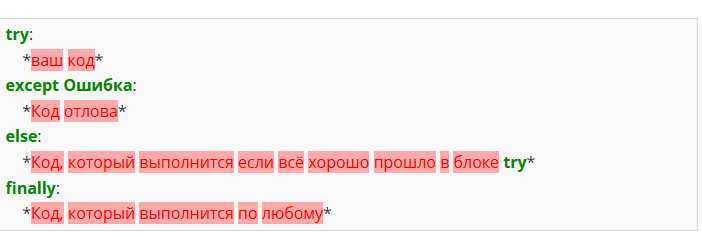

In [6]:
try:
    print("Перед исключением")
    a = int(input("a: "))
    b = int(input("b: "))
    c = a / b
    print(c)  # печатаем c = a / b если всё хорошо
except ZeroDivisionError as e:
    print("После исключения")
else:  # код в блоке else выполняется только в том случае, если код в блоке try выполнился успешно (т.е. не вылетело никакого исключения).
    print("Всё ништяк")
finally:  # код в блоке finally выполнится в любом случае, при выходе из try-except
    print("Finally на месте")
 
print("После После исключения")

Перед исключением
0.5
Всё ништяк
Finally на месте
После После исключения


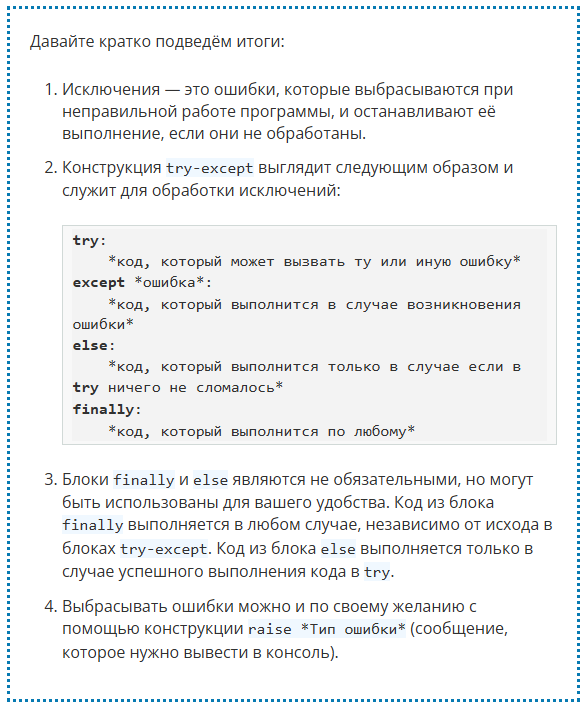

Задание 8.7
Задание на самопроверку.

Создать скрипт, который будет в input() принимать строки, и их необходимо будет конвертировать в числа, добавить try-except на то, чтобы строки могли быть сконвертированы в числа.

В случае удачного выполнения скрипта написать: «Вы ввели <введённое число>».

В конце скрипта обязательно написать: «Выход из программы».

ПРИМЕЧАНИЕ: Для отлова ошибок используйте try-except, а также блоки finally и else.

In [6]:
try: 
    print('Введите данные для конвертации:')
    b = int(input())
except ValueError:
    print('Вы сделали не совсем удачную попытку, введите число')
else: 
    print(f'Вы ввели <введённое число {b}')
finally: 
    print('Выход из программы')
        

Введите данные для конвертации:
Вы ввели <введённое число 9
Выход из программы


### Тонкости обработки исключений. Собственные классы исключений

ArithmeticError является более абстрактным (находящимся выше в иерархическом дереве, родительским) классом. Если вы хотите ловить сначала исключения-потомки, а затем родительские исключения, убедитесь, что в блоке except отлов родительского исключения стоит ниже, чем отлов исключения-потомка. Иначе говоря, ваша конструкция отлова исключений должна идти от конкретного класса к более абстрактному.

Действуя от обратного, однако, надо быть осторожным. Если, например, надо поймать несколько исключений, то идти следует вверх по дереву.

In [8]:
try: 
    raise ZeroDivisionError
except ArithmeticError: 
    print('Arithmetic Error')
except ZeroDivisionError: 
    print('Zero division error')

Arithmetic Error


In [7]:
try: 
    raise ZeroDivisionError
except ZeroDivisionError: 
    print('Zero division error')
except ArithmeticError: 
    print('Arithmetic Error')

Zero division error


Если кратко обобщить, то можно сказать так: исключения — это тоже классы. Будучи классами, они могут наследоваться. «Отлавливать» можно как сам класс, так и его родителя (в любом колене). В этом случае надо убедиться в том, чтобы сначала обрабатывались более конкретные исключения, иначе они могут быть перекрыты их родителями и попросту упущены.

Принцип написания и отлова **собственного** исключения следующий:

In [ ]:
class MyException(Exception):  # создаём пустой класс исключения 
    pass

 
try:
    raise MyException("message")  # поднимаем наше исключение
except MyException as e:  # ловим его
    print(e)  # выводим информацию об исключении

Давайте теперь попробуем построить собственные исключения с наследованием:



In [2]:
class ParentException(Exception): # создаем пустой класс исключения, наследуемся от exception 
    pass 
class ChildExeption(ParentException): # создаем пустой класс исключения-потомка, наследуемся от ParentException
    pass 
try: 
    raise ChildExeption('message') # поднимаем исключение-потомок 
except ParentException as e: # ловим его родителя
    print(e) # выводим информацию об исключении 
    


message


Кстати говоря, класс с самописным исключением необязательно должен быть пустым. Если вы хотите добавить собственные аргументы в конструктор, дополнительно произвести какие-либо операции, то можете спокойно это делать, главное — не забыть о нескольких нюансах:

In [3]:
class ParentException(Exception): 
    def __init__(self, message, error): # допишем к нашему пустому классу конструктор, который будет печатать дополнительно 
        # в консоль информацию об ошибке. 
        super().__init__(message) # помни про вызов конструктора родительского класса 
        print(f'Errors:{error}') # печатаем ошибку 

class ChildExeption(ParentException): # создаем пустой класс исключения-потомка, наследуемся от ParentException 
    def __init__(self, message, error):
        super().__init__(message, error)
try: 
    raise ChildExeption('message', 'error') # поднимаем исключение-потомок, передаем дополнительный аргумент 
except ParentException as e: 
    print(e) # выводим информацию об исключении 

    

Errors:error
message


Задание 9.5

Создайте класс Square. Добавьте в конструктор класса Square собственное исключение NonPositiveDigitException, унаследованное от ValueError, которое будет срабатывать каждый раз, когда сторона квадрата меньше или равна 0.

In [ ]:
class NonPositiveDigitException(ValueError): # наследуемся от ValueError  
    pass 
        
class Square():
    def __init__(self):
        if a <= 0: raise NonPositiveDigitException ('Неправильнор указана сторона квадрата')

      


<strong> Markdown </strong>